# 01  Data Loader & Feature Engineering

- Load the single wide price matrix (date × ticker)
- Build the point-in-time stock universe and apply it as a mask to the price frame
- Forward-fill short gaps in the price series (capped at 5 trading days) and flag stale prices to avoid contaminating volatility estimates
- Convert to long format
- Compute the features
- Add country / region from the exchange suffix
- Map each company into the corresponding GICS sector to compute sector-relative returns
- Define two benchmarks: retrieve SXXR data from the benchmark sheet and build EW-SXXR from the in-universe constituents
- Save to processed CSV

In [2]:
import json, yaml
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, time

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 4), "figure.dpi": 100})

## Configuration

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

RAW_BLOOMBERG = PROJECT_ROOT / cfg["data"]["raw_bloomberg"]
PROCESSED_DIR = PROJECT_ROOT / cfg["data"]["processed_dir"]
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

START_YEAR = cfg["start_year"]
END_YEAR = cfg["end_year"]
CSV_LAST_YEAR = cfg["csv_last_year"]
RETURN_HORIZONS = cfg["return_horizons"]     
VOL_WINDOWS = cfg["vol_windows"]

## Load raw prices and define year by year stock universe

The unique data source is SXXR.xlsx pulled from Bloomberg terminal. Four sheets:
- `year_by_year`: STOXX 600 constituents per year (point-in-time), each column lists the constituents at the start of that year.
- `unique_tickers`: union of all tickers ever in the index over the period
- `stocks`: wide price matrix, dates × tickers (header includes the " Equity" suffix, e.g. "AD NA Equity")
- `benchmark`: SXXR Index closing prices

The data is available from 01/01/2006 to 06/05/2026.

Empty cells in `stocks` mean either (a) the local exchange was closed on that day due to festivity, or (b) the ticker had no data for that day. Both become NaN when we read the file; the universe mask later disambiguates the two.

In [4]:
def _strip_equity_suffix(col: str) -> str:
    s = str(col).strip()
    return s[:-len(" Equity")] if s.endswith(" Equity") else s

prices_wide = pd.read_excel(RAW_BLOOMBERG, sheet_name="stocks")
prices_wide = prices_wide.set_index(prices_wide.columns[0])
prices_wide.index = pd.to_datetime(prices_wide.index, errors="coerce")
prices_wide.index.name = "date"
prices_wide = prices_wide[prices_wide.index.notna()].sort_index()
prices_wide = prices_wide[~prices_wide.index.duplicated(keep="last")]
prices_wide.columns = [_strip_equity_suffix(c) for c in prices_wide.columns]
prices_wide = prices_wide.apply(pd.to_numeric, errors="coerce")
prices_wide = prices_wide.loc[str(START_YEAR):str(END_YEAR)]

print(f"Bloomberg prices loaded: {prices_wide.shape[0]} dates x {prices_wide.shape[1]} tickers"
      f" ({prices_wide.index.min().date()} → {prices_wide.index.max().date()})")
print(f"  Overall NaN fraction: {prices_wide.isna().mean().mean():.2%}")

# Read year-by-year universe --> wide sheet with one column per year; parse into a dict {year: [tickers]}.
# year_by_year sheet has NO header row; columns A..T = years START_YEAR..START_YEAR+19
yby = pd.read_excel(RAW_BLOOMBERG, sheet_name="year_by_year", header=None)

n_year_cols = yby.shape[1]
years = list(range(START_YEAR, START_YEAR + n_year_cols))
yby.columns = years

universe_by_year = {}
for year in years:
    members = yby[year].dropna().astype(str).map(_strip_equity_suffix).str.strip()
    members = members[members != ""].tolist()
    universe_by_year[year] = sorted(set(members))

print(f"Universe loaded: {len(universe_by_year)} years")
print(f"  Range: {min(universe_by_year)} - {max(universe_by_year)}")
print(f"  Members per year: {[len(universe_by_year[y]) for y in sorted(universe_by_year)]}")

Bloomberg prices loaded: 5308 dates x 777 tickers (2006-01-02 → 2026-05-06)
  Overall NaN fraction: 26.54%
Universe loaded: 21 years
  Range: 2006 - 2026
  Members per year: [600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600, 600]


### Apply point-in-time masking

Using `universe_by_year` from the `year_by_year` sheet, we zero out prices for `(date, ticker)` pairs where the ticker was not a STOXX 600 constituent in that calendar year. This allows to correctly deal with surivorship bias.

In [5]:
mask = pd.DataFrame(False, index=prices_wide.index, columns=prices_wide.columns)
for year, members in universe_by_year.items():
    in_year = prices_wide.index.year == year
    valid_members = [t for t in members if t in prices_wide.columns]
    if valid_members and in_year.any():
        mask.loc[in_year, valid_members] = True

n_before = prices_wide.notna().sum().sum()
prices_wide = prices_wide.where(mask)
n_after = prices_wide.notna().sum().sum()
print(f"Universe mask applied: kept {n_after:,} / {n_before:,} price cells "
      f"({100 * n_after / max(n_before, 1):.1f}%)")

Universe mask applied: kept 2,319,235 / 3,029,876 price cells (76.5%)


### Clean the prices 

We did not drop the entire row with NaNs bc this would remove too much data nor use linear interpolation since it uses future prices to fill the present, which introduces look-ahead bias. We opted instead for the **foward-fill** techinque.

Three layers of cleaning, applied in order on the wide matrix: 
1. Forward-fill missing prices, capped at `MAX_FFILL_DAYS` to avoid propagating stale prices through long suspensions.
2. Track which cells were ffilled so we can mask the corresponding returns to NaN later (a return computed across an ffilled segment is not a real return). In particular, `ffill` guarantees a continuous price series but it creates fictitious one-day returns wherever the fill operates: a zero return on the filled day (price carried forward) and a multi-day return mislabeled as one-day on the recovery day (real price compared against a stale one). We therefore null the 1d return on any day whose price, or whose previous price, was forward-filled (or stale), so that returns are only computed between two genuinely observed prices. Multi-horizon returns are unaffected as long as their endpoints are real, which is automatic since stale interior days are kept in the price series. Therefore, we ffill so MACD and EWMA-based features have a continuous price input.
3. Detect **stale prices** (consecutive identical close prices) which corrupt realized vol / EWMA vol estimates if left as zero returns. A 0 return from staleness is not the same signal as a 0 return from a genuinely flat day, so we substitue them with NaNs.

In [6]:
observed_mask = prices_wide.notna() # "was this cell originally observed?" before any filling

MAX_FFILL_DAYS = 5
prices_filled = prices_wide.ffill(limit=MAX_FFILL_DAYS) # max forward-fill length (days); beyond this, treat as missing

# Cells that are now non-NaN but weren't originally --> these came from ffill.
# We'll use this to invalidate returns computed across ffilled segments.
ffill_mask = prices_filled.notna() & ~observed_mask

# Stale-price detection: p_t = p_t-1, both observed, and we're within the same ticker (handled column-wise so it's automatic)
prev_prices = prices_filled.shift(1)
stale_mask = (
    (prices_filled - prev_prices).abs() < 1e-10 # this act as a stale tolerance (for "same price as yesterday")
) & observed_mask & observed_mask.shift(1).fillna(False)

n_obs = observed_mask.sum().sum()
n_ffilled = ffill_mask.sum().sum()
n_stale = stale_mask.sum().sum()
print(f"Originally observed cells:  {n_obs:,}")
print(f"Cells filled by ffill:      {n_ffilled:,} ({100*n_ffilled/max(n_obs,1):.2f}% of observed)")
print(f"Stale-price cells flagged:  {n_stale:,} ({100*n_stale/max(n_obs,1):.2f}% of observed)")
print(f"Cells still NaN after fill: {prices_filled.isna().sum().sum():,}")

# Replace the wide frame with the filled version
prices_wide = prices_filled

Originally observed cells:  2,319,235
Cells filled by ffill:      72,495 (3.13% of observed)
Stale-price cells flagged:  40,049 (1.73% of observed)
Cells still NaN after fill: 1,732,586


## Convert to long format

In [7]:
df = (
    prices_wide
    .stack(future_stack=True)
    .reset_index()
    .rename(columns={"level_1": "ticker", 0: "price"})
)
df.columns = ["date", "ticker", "price"]
df = df.dropna(subset=["price"]).sort_values(["ticker", "date"]).reset_index(drop=True)

# Bring the cleaning flags along in long format
ffill_long = ffill_mask.stack(future_stack=True).rename("is_ffilled").reset_index()
ffill_long.columns = ["date", "ticker", "is_ffilled"]
stale_long = stale_mask.stack(future_stack=True).rename("is_stale").reset_index()
stale_long.columns = ["date", "ticker", "is_stale"]

df = df.merge(ffill_long, on=["date", "ticker"], how="left")
df = df.merge(stale_long, on=["date", "ticker"], how="left")
df["is_ffilled"] = df["is_ffilled"].fillna(False)
df["is_stale"] = df["is_stale"].fillna(False)

print(f"Long format:  {len(df):,} rows x {df['ticker'].nunique()} tickers")
print(f"ffilled rows: {df['is_ffilled'].sum():,}")
print(f"stale rows:   {df['is_stale'].sum():,}")

Long format:  2,391,730 rows x 776 tickers
ffilled rows: 72,495
stale rows:   40,049


## Features

For each stock $i$ and horizon $h \in \{1, 21, 63, 126, 252\}$:

- **Arithmetic returns** over $h$ days: $r_{t, h}^{(i)} = \frac{p_t^{(i)}-p_{t-h}^{(i)}}{p_{t-h}^{(i)}}$
- **Log returns** over $h$ days: $R_{t, h}^{(i)} = \ln\left(\frac{p_t^{(i)}}{p_{t-h}^{(i)}}\right)$
- **Annualized realized rolling volatility**: $\sigma_{t, w}^{(i)} = \sqrt{252} \cdot \sqrt{\frac{1}{w-1} \sum_{j=0}^{w-1} \left( r_{t-j, 1}^{(i)} - \bar{r} \right)^2}$
- **60-day EWMA volatility**, both daily and annualised forms: $\sigma_{t,\text{daily}}^{(i)} = \sqrt{\frac{\sum_{j} (1-\alpha)^j (r_{t-j,1}^{(i)} - \bar{r}_t)^2}{\sum_j (1-\alpha)^j}}$ with $\alpha = 2/61$, and $\sigma_t^{(i)} = \sqrt{252} \cdot \sigma_{t,\text{daily}}^{(i)}$. The daily form is the $\sigma_t^{(i)}$ in the paper's Eq. 11; the annualised form is used for the Sharpe-loss vol scaling.
- **Paper-style normalised returns** (LSTM inputs): $\tilde{r}_{t, h}^{(i)} = \frac{r_{t-h,t}^{(i)}}{\sigma_{t,\text{daily}}^{(i)} \sqrt{h}}$. The sqrt-time scaling produces approximately $\mathcal{N}(0, 1)$ features comparable across stocks and horizons.
- **Vol-normalized MACD indicators** (Baz et al. 2015): $\text{MACD}_t^{(i)}(S, L) = \frac{\text{EWMA}_t(p^{(i)}, S) - \text{EWMA}_t(p^{(i)}, L)}{p_t^{(i)} \cdot \sigma_{t,\text{daily}}^{(i)}}$ with pairs $(S, L) \in \{(8, 24), (16, 48), (32, 96)\}$.


In [8]:
with open("../configs/default.yaml", "r") as file:
    config = yaml.safe_load(file)

RETURN_HORIZONS = config["return_horizons"]
VOL_WINDOWS = config["vol_windows"]
MACD_PAIRS = config["macd_pairs"]
 
df = df.sort_values(["ticker", "date"])
g_price = df.groupby("ticker")["price"]

df["1d_arith_ret"] = g_price.transform(lambda s: s.pct_change(1))
df["1d_log_ret"] = g_price.transform(lambda s: np.log(s).diff(1))
g_arith_1d = df.groupby("ticker")["1d_arith_ret"]

# Invalidate 1d returns that were computed across an ffilled segment (today is observed but yesterday was ffill OR today is ffill)
g_ffilled = df.groupby("ticker")["is_ffilled"]
prev_ffilled = g_ffilled.shift(1).fillna(False)
bad_ret = df["is_ffilled"] | prev_ffilled | df["is_stale"]

df.loc[bad_ret, "1d_arith_ret"] = np.nan
df.loc[bad_ret, "1d_log_ret"]  = np.nan

n_bad = bad_ret.sum()
print(f"Invalidated {n_bad:,} 1-day returns ({100*n_bad/len(df):.2f}%) due to ffill or staleness")

g_arith_1d = df.groupby("ticker")["1d_arith_ret"] # Now re-create g_arith_1d so it sees the cleaned 1d returns

# Multi-horizon arith and log returns
for d, label in RETURN_HORIZONS:
    if d > 1: # 1d is already computed above
        df[f"{label}_arith_ret"] = g_price.transform(lambda s: s.pct_change(d))
        df[f"{label}_log_ret"] = g_price.transform(lambda s: np.log(s).diff(d))

# Realized volatility (annualized) (for LSTM features)
for w, label in VOL_WINDOWS:
    df[f"{label}_vol"] = g_arith_1d.transform(lambda s: s.rolling(w, min_periods=w).std() * np.sqrt(252))

# 60d EWMA vol (compute daily vol first, then annualise)
# This is sigma_t^(i) in the paper (Eq. 11), used everywhere a causal ex-ante vol is needed
df["60d_ewm_vol_daily"] = g_arith_1d.transform(
    lambda s: s.ewm(span=60, min_periods=21).std()
)
df["60d_ewm_vol"] = df["60d_ewm_vol_daily"] * np.sqrt(252)

# Paper-style normalised returns for the LSTM (Lim, Zohren & Roberts 2019, "Model inputs"):
#   r_norm_{t, t'} = r_{t-t', t} / (sigma_t * sqrt(t'))
# where sigma_t is the 60d EWMA daily vol and t' is the return horizon.
# Produces approximately N(0, 1) features comparable across stocks and horizons.
for d, label in RETURN_HORIZONS:
    arith = f"{label}_arith_ret"
    if arith in df.columns:
        df[f"{label}_norm_ret"] = df[arith] / (
            df["60d_ewm_vol_daily"].replace(0.0, np.nan) * np.sqrt(d)
        )

# Vol-normalized MACD indicators (Baz et al. 2015, denominator uses daily ex-ante vol)
for S, L in MACD_PAIRS:
    ewm_S = g_price.transform(lambda s: s.ewm(span=S, min_periods=S).mean())
    ewm_L = g_price.transform(lambda s: s.ewm(span=L, min_periods=L).mean())
    df[f"macd_{S}_{L}"] = (ewm_S - ewm_L) / (
        df["price"] * df["60d_ewm_vol_daily"].replace(0.0, np.nan)
    )

df.tail(10)

Invalidated 160,072 1-day returns (6.69%) due to ffill or staleness


,date,ticker,price,is_ffilled,is_stale,1d_arith_ret,1d_log_ret,21d_arith_ret,21d_log_ret,63d_arith_ret,...,60d_ewm_vol_daily,60d_ewm_vol,1d_norm_ret,21d_norm_ret,63d_norm_ret,126d_norm_ret,252d_norm_ret,macd_8_24,macd_16_48,macd_32_96
2391720,2017-12-25,ZURN SW,298.0,True,False,NaN,NaN,-0.000335,-0.000336,0.040503,...,0.007242,0.114965,NaN,-0.010108,0.704609,0.833010,0.371305,0.188145,0.514890,1.507109
2391721,2017-12-26,ZURN SW,298.0,True,False,NaN,NaN,0.016718,0.016580,0.028295,...,0.007242,0.114965,NaN,0.503738,0.492242,0.574662,0.377656,0.101332,0.461984,1.467789
2391722,2017-12-27,ZURN SW,298.2,False,False,NaN,NaN,0.015668,0.015546,0.009479,...,0.007242,0.114965,NaN,0.472091,0.164896,0.587831,0.415659,0.050557,0.421826,1.432524
2391723,2017-12-28,ZURN SW,297.8,False,False,-0.001341,-0.001342,0.007442,0.007415,0.008466,...,0.007114,0.112924,-0.188568,0.228309,0.149941,0.525834,0.427035,-0.013220,0.379076,1.418853
2391724,2017-12-29,ZURN SW,296.6,False,False,-0.004030,-0.004038,-0.002019,-0.002021,0.002705,...,0.007025,0.111524,-0.573574,-0.062708,0.048501,0.465392,0.391228,-0.142218,0.295449,1.378803
2391725,2018-01-01,ZURN SW,296.6,True,False,NaN,NaN,0.008501,0.008465,0.008844,...,0.007025,0.111524,NaN,0.264039,0.158595,0.428735,0.521432,-0.231837,0.217912,1.318499
2391726,2018-01-02,ZURN SW,296.6,True,False,NaN,NaN,-0.004030,-0.004038,0.004402,...,0.007025,0.111524,NaN,-0.125164,0.078948,0.324475,0.407721,-0.291842,0.151243,1.261370
2391727,2018-01-03,ZURN SW,296.6,True,False,NaN,NaN,-0.001683,-0.001684,0.007473,...,0.007025,0.111524,NaN,-0.052275,0.134013,0.447038,0.480985,-0.329592,0.094092,1.207233
2391728,2018-01-04,ZURN SW,296.6,True,False,NaN,NaN,-0.000337,-0.000337,0.007131,...,0.007025,0.111524,NaN,-0.010469,0.127878,0.306512,0.589618,-0.350744,0.045271,1.155918
2391729,2018-01-05,ZURN SW,296.6,True,False,NaN,NaN,-0.001347,-0.001348,0.005083,...,0.007025,0.111524,NaN,-0.041834,0.091156,0.270734,0.599930,-0.359644,0.003735,1.107262


In [9]:
print(f"Full range: {df['date'].min()} → {df['date'].max()}")
print(f"Total rows: {len(df):,}")
print(f"Total tickers: {df['ticker'].nunique()}")

Full range: 2006-01-02 00:00:00 → 2026-05-06 00:00:00
Total rows: 2,391,730
Total tickers: 776


## Mapping countries, regions and (GICS) sectors

Sector mapping is loaded from `src/sector_mapping.py`, a standalone dict of Bloomberg ticker → GICS sector.

After tagging each row with its sector we compute sector-relative returns: $$r_{i,t}^{\text{rel}} = r_{i,t} - \bar{r}_{\text{sector}_i,\,t}^{\text{EW}}$$ where $\bar{r}_{\text{sector}_i,t}^{\text{EW}}$ is the equal-weighted mean return across all constituents of the same sector on date $t$.

For each return horizon, add a <label>_sec_rel_ret column. Uses groupby + transform so no explicit date loop (vectorised over 1.6M rows).
IMPORTANT timing: ${r}_{\text{sector}_i,t}^{\text{EW}}$ is computed from constituents at time $t$. For feature engineering this is fine (we're describing past behaviour). When feeding the DMN at time $t$, use ${r}_{\text{sector}_i,t-1}^{\text{EW}}$ shifted back by 1 day.

In [ ]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))  # makes `src` importable
from src.sector_mapping import SECTOR_MAP, get_sector

EXCHANGE_TO_COUNTRY = {
    "LN": "United Kingdom", "FP": "France",       "GY": "Germany",
    "NA": "Netherlands",    "IM": "Italy",        "SQ": "Spain",
    "SM": "Spain",          "SE": "Switzerland",  "SW": "Switzerland",
    "SS": "Sweden",         "DC": "Denmark",      "FH": "Finland",
    "NO": "Norway",         "BB": "Belgium",      "AV": "Austria",
    "PL": "Portugal",       "ID": "Ireland",      "PW": "Poland",
}
COUNTRY_TO_REGION = {
    "United Kingdom": "UK & Ireland", "Ireland": "UK & Ireland",
    "France": "Western Europe",  "Germany": "Western Europe", "Netherlands": "Western Europe",
    "Belgium": "Western Europe", "Austria": "Western Europe", "Switzerland": "Western Europe",
    "Italy": "Southern Europe", "Spain": "Southern Europe", "Portugal": "Southern Europe",
    "Sweden": "Nordic", "Denmark": "Nordic", "Finland": "Nordic", "Norway": "Nordic",
    "Poland": "Eastern Europe",
}
 
df["exchange"] = df["ticker"].str.split().str[-1]
df["country"] = df["exchange"].map(EXCHANGE_TO_COUNTRY)
df["region"] = df["country"].map(COUNTRY_TO_REGION)
df["sector"] = df["ticker"].map(SECTOR_MAP).fillna("Unknown")
 
n_unknown_tickers = df.loc[df["sector"] == "Unknown", "ticker"].nunique()
if n_unknown_tickers:
    missing = df.loc[df["sector"] == "Unknown", "ticker"].unique().tolist()
    print(f"WARNING: {n_unknown_tickers} tickers not in SECTOR_MAP, add them to src/sector_mapping.py")
    print("  Missing:", missing[:20], "..." if len(missing) > 20 else "")
else:
    print("All tickers mapped to a sector")
 
print("\nSector distribution (unique tickers):")
print(df.groupby("sector")["ticker"].nunique().sort_values(ascending=False).to_string())

# Compute sector-relative returns (uncomment to add log)
for _, label in RETURN_HORIZONS:

    #raw_log = f"{label}_log_ret"
    #rel_log = f"{label}_log_ret_rel"
    #if raw_log in df.columns:
    #    sector_mean_log = df.groupby(["date", "sector"])[raw_log].transform("mean")
    #    df[rel_log] = df[raw_log] - sector_mean_log

    raw_arith = f"{label}_arith_ret"
    rel_arith = f"{label}_arith_ret_rel"
    if raw_arith in df.columns:
        sector_mean_arith = df.groupby(["date", "sector"])[raw_arith].transform("mean")
        df[rel_arith] = df[raw_arith] - sector_mean_arith
 
print("\nCountry distribution (unique tickers):")
print(df.groupby("country")["ticker"].nunique().sort_values(ascending=False).head(10).to_string())

  Missing: ['0876218D LN', '1294047D SS', '1340426D GY', '1448841D LN', '1572241D SQ', '1643322D NO', '1654144D SE', '1655637D LN', '1767729D LN', '1816878D LN', '1837977D LN', '1844030D NA', '1854706D IM', '1856607D IM', '1926157D LN', '1937542D LN', '1986986D LN', '2462936D LN', '2614591D GA', '3014039Q LN'] ...

Sector distribution (unique tickers):
sector
Industrials               181
Financials                135
Communication Services     67
Consumer Discretionary     66
Materials                  55
Health Care                50
Consumer Staples           44
Information Technology     42
Unknown                    39
Utilities                  36
Energy                     31
Real Estate                30

Country distribution (unique tickers):
country
United Kingdom    233
France             97
Germany            72
Italy              50
Switzerland        50
Spain              47
Sweden             43
Netherlands        40
Finland            25
Denmark            22


## Finalise column order

In [11]:
ret_cols = []
rel_cols = []
for _, lbl in RETURN_HORIZONS:
    ret_cols.extend([f"{lbl}_arith_ret", f"{lbl}_log_ret"])
    rel_cols.extend([f"{lbl}_arith_ret_rel"]) # add f"{lbl}_log_ret_rel" if needed

norm_cols = [f"{lbl}_norm_ret" for _, lbl in RETURN_HORIZONS]
vol_cols  = [f"{lbl}_vol" for _, lbl in VOL_WINDOWS] + ["60d_ewm_vol_daily", "60d_ewm_vol"]
macd_cols = [f"macd_{S}_{L}" for S, L in MACD_PAIRS]

cols = (["date", "ticker", "price"]
        + ret_cols
        + rel_cols
        + norm_cols
        + vol_cols
        + macd_cols
        + ["sector", "exchange", "country", "region", "is_ffilled", "is_stale"]) 
 
# only keep columns that actually exist
cols = [c for c in cols if c in df.columns]
df = df[cols].sort_values(["date", "ticker"]).reset_index(drop=True)

total_rows = len(df); total_cells = df.size; total_nans = df.isna().sum().sum()
print(f"Final stock df: {total_rows:,} rows x {len(df.columns)} cols")
print(f"Total NaN cells: {total_nans:,} / {total_cells:,} ({total_nans/total_cells:.2%})")
df.tail()

Final stock df: 2,391,730 rows x 38 cols
Total NaN cells: 10,304,819 / 90,885,740 (11.34%)


,date,ticker,price,1d_arith_ret,1d_log_ret,21d_arith_ret,21d_log_ret,63d_arith_ret,63d_log_ret,126d_arith_ret,...,60d_ewm_vol,macd_8_24,macd_16_48,macd_32_96,sector,exchange,country,region,is_ffilled,is_stale
2391725,2026-05-06,WKL NA,63.42,-0.073349,-0.076178,-0.020087,-0.020291,-0.063220,-0.065307,-0.338134,...,0.396877,-0.001825,-0.557713,-4.320866,Information Technology,NA,Netherlands,Western Europe,False,False
2391726,2026-05-06,WPP LN,274.15,0.003477,0.003471,0.111719,0.105908,0.023712,0.023435,-0.095215,...,0.416236,0.962812,0.425730,-2.366958,Communication Services,LN,United Kingdom,UK & Ireland,False,False
2391727,2026-05-06,WRT1V FH,37.00,0.028063,0.027677,0.136364,0.127833,0.083138,0.079863,0.360294,...,0.442619,0.503198,1.121433,1.948040,Industrials,FH,Finland,Nordic,False,False
2391728,2026-05-06,WTB LN,2346.00,0.035762,0.035137,-0.018410,-0.018582,-0.127557,-0.136458,-0.183432,...,0.338586,-1.111058,-1.269788,-2.300734,Consumer Discretionary,LN,United Kingdom,UK & Ireland,False,False
2391729,2026-05-06,YAR NO,529.60,-0.041968,-0.042874,-0.112601,-0.119460,0.163956,0.151825,0.427493,...,0.466191,-0.025455,0.838283,2.675904,Materials,NO,Norway,Nordic,False,False


## Benchmarks

- **SXXR** (cap-weighted index) from the `benchmark` sheet of the xlsx 
- **EW** (equal-weighted syntetic index) built from the combined wide prices 

They are stacked together in one long dataframe

In [12]:
sxxr_raw = pd.read_excel(RAW_BLOOMBERG, sheet_name="benchmark")
sxxr_raw = sxxr_raw.set_index(sxxr_raw.columns[0])
sxxr_raw.index = pd.to_datetime(sxxr_raw.index, errors="coerce")
sxxr = pd.to_numeric(sxxr_raw.iloc[:, 0], errors="coerce").dropna()
sxxr.name = "SXXR"; sxxr.index.name = "date"
print(f"SXXR loaded: {len(sxxr):,} obs ({sxxr.index.min().date()} → {sxxr.index.max().date()})")

prev_prices = prices_wide.shift(1)
ret_wide = (prices_wide / prev_prices) - 1.0
# This automatically yields NaN whenever either endpoint is NaN, including at universe entry/exit boundaries.

# Equal-weighted daily return: average across tickers that have a valid return today
ew_ret = ret_wide.mean(axis=1, skipna=True)

# Cumulate from 100. fillna(0) is correct here because a missing daily return
# (no in-universe stocks that day, which shouldn't happen but defensive) means no portfolio movement.
ew_level = 100 * (1 + ew_ret.fillna(0)).cumprod()
ew_level.iloc[0] = 100
ew_level.name = "EW"; ew_level.index.name = "date"

print(f"EW benchmark:  {len(ew_level):,} obs ({ew_level.index.min().date()} → {ew_level.index.max().date()})")
print(f"  Final level: {ew_level.iloc[-1]:.1f}  (started at 100)")
print(f"  Annualized return: {(ew_level.iloc[-1]/100)**(252/len(ew_level)) - 1:.2%}")

# Convert to long format
benchmarks_wide = pd.concat([sxxr, ew_level], axis=1)
benchmarks = benchmarks_wide.reset_index().melt(
    id_vars="date", 
    value_vars=["SXXR", "EW"], 
    var_name="benchmark", 
    value_name="price"
).dropna().sort_values(["date", "benchmark"]).reset_index(drop=True)

print(f"\nBenchmark df:  {len(benchmarks):,} rows")
benchmarks.tail()

SXXR loaded: 5,221 obs (2006-01-02 → 2026-05-06)
EW benchmark:  5,308 obs (2006-01-02 → 2026-05-06)
  Final level: 259.4  (started at 100)
  Annualized return: 4.63%

Benchmark df:  10,529 rows


,date,benchmark,price
10524,2026-05-04,SXXR,1531.460000
10525,2026-05-05,EW,253.797917
10526,2026-05-05,SXXR,1542.750000
10527,2026-05-06,EW,259.382533
10528,2026-05-06,SXXR,1577.420000


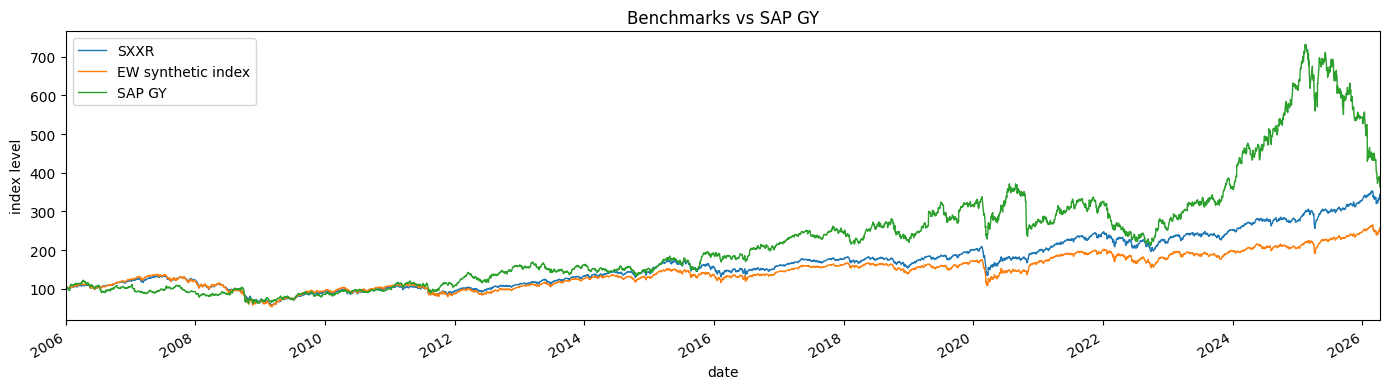

In [17]:
STOCK = "SAP GY"   # some examples of single stocks: ASML NA, SAP GY, AZN LN, SAN FP, TTE FP, HSBA LN
stock_prices = df.loc[df["ticker"] == STOCK].set_index("date")["price"]

def rebase(s, base=100.0): # rebased to 100
    s = s.dropna()
    return base * s / s.iloc[0] if len(s) else s

fig, ax = plt.subplots()
if len(sxxr):
    rebase(sxxr).plot(ax=ax, linewidth=1, label="SXXR")
rebase(ew_level).plot(ax=ax, linewidth=1, label="EW synthetic index")
rebase(stock_prices).plot(ax=ax, linewidth=1, label=STOCK)
#ax.set_yscale("log")
ax.set_title(f"Benchmarks vs {STOCK}") 
ax.set_ylabel("index level")
ax.set_xlim("2006-01-01", "2026-04-10")
ax.legend()
plt.tight_layout()
plt.show()

# Some data diagnostics

**check single stocks' membership across years**

In [18]:
# Sanity check: are all tickers in year_by_year present in stocks sheet?
yby_tickers = {t for ts in universe_by_year.values() for t in ts}
prices_tickers = set(prices_wide.columns)

print(f"Tickers in year_by_year:        {len(yby_tickers):>5}")
print(f"Tickers in stocks sheet:        {len(prices_tickers):>5}")
print(f"In year_by_year but not stocks: {len(yby_tickers - prices_tickers):>5}")
print(f"In stocks but never in universe:{len(prices_tickers - yby_tickers):>5}")

missing = yby_tickers - prices_tickers
if missing:
    print(f"\n Missing from stocks sheet: {sorted(missing)[:10]}")

Tickers in year_by_year:         1314
Tickers in stocks sheet:          777
In year_by_year but not stocks:   537
In stocks but never in universe:    0

 Missing from stocks sheet: ['1918505D NA', '1CNHI IM', '1COV GY', '1U1 GY', '2261689D LN', '2578464D GY', '2627525D LN', '63DU GY', 'AA/ LN', 'AAF LN']


## Save to processed CSV

In [19]:
stock_path = PROCESSED_DIR / "stoxx600_processed.csv"
bench_path = PROCESSED_DIR / "benchmark_stoxx600_ew.csv"

df.to_csv(stock_path, index=False)
benchmarks.to_csv(bench_path, index=False)

print(f"Saved stocks:      {stock_path}  ({stock_path.stat().st_size / 1e6:.1f} MB)")
print(f"Saved benchmarks:  {bench_path}  ({bench_path.stat().st_size / 1e6:.1f} MB)")

Saved stocks:      c:\Users\vonae\Documents\GitHub\Pergam_MSc_2026\data\processed\stoxx600\stoxx600_processed.csv  (1387.9 MB)
Saved benchmarks:  c:\Users\vonae\Documents\GitHub\Pergam_MSc_2026\data\processed\stoxx600\benchmark_stoxx600_ew.csv  (0.3 MB)


**Final comments/open problems-questions**:
- ofc we end up having ~252 NaNs per ticker for `252d_*` features and so on from the other rolling windows: we do not `dropna` on them at this stage, because these are structural.
- we still need to upload the xlsx with the missing companies (from the 777th and so on)
- modify the sector mapping accordingly, this should have been done, but read the comments on sector_mapping.py, verify if all the companies are mapped correctly and if the number of stocks is consistent (use a count)
- how to manage delisted stocks 19384929? They cannot be mapped and identified correctly so maybe we can just get rid of them?